In [6]:



import numpy as np
import pandas as pd

from compecon.ode import ODE
from compecon.tools import Options_Container, gridmake
import time

In [7]:
class OCoptions(Options_Container):
    description = "Solver options for a OCmodel"

    def __init__(self, tol=np.sqrt(np.spacing(1)), maxit=80, show=True, nr=10):
        self.tol = tol
        self.maxit = maxit
        self.show = show
        self.nr = nr

    def print_header(self):
        if self.show:
            print('Solving optimal control model')
            print('{:4s} {:12s} {:8s}'.format('iter', 'change', 'time'))
            print('-' * 30)

    def print_current_iteration(self, it, change, tic):
        if self.show:
            print(f'{it:4d}  {change:12.1e}  {time.time() - tic:8.4f}')

    def print_last_iteration(self, tic, change):
        if self.show:
            if change >= self.tol:
                print('Failure to converge in OCmodel.solve()')
            print(f'Elapsed Time = {time.time() - tic:7.2f} Seconds')


In [49]:
class OCmodel(object):

    def __init__(self, *, basis, control, reward, drift, diffusion=None, rho=0.0, Vss=False, states=['s'], controls=['x'], params=[]):
        
        ds = basis.d #dimension of state variable
        
        assert callable(control), 'control must be a function'
        assert callable(reward), 'reward must be a function'
        assert callable(drift), 'drift (transition) must be a function'

        if Vss:
            self.__x = lambda s, Vs, Vss: np.asarray(control(s, Vs, Vss, *params))
            self.__needsVss = True
        else:
            self.__x = lambda s, Vs: np.asarray(control(s, Vs, *params))
            self.__needsVss = False

        self.__f = lambda s, x: np.asarray(reward(s, x, *params))
        self.__μ = lambda s, x: np.asarray(drift(s, x, *params))

        if diffusion:
            assert callable(diffusion), 'diffusion must be a function'
            self.__σ = lambda s,x: diffusion(s, x, *params).reshape(ds,ds,-1)
            self.__isStochastic = True
        else:
            self.__isStochastic = False

        # Labels
        self.states = [states] if isinstance(states, str) else states
        self.controls = controls if isinstance(controls, str) else controls

        basis.opts.labels = self.states

        #  Value and policy functions
        self.Value = basis.duplicate()
        self.Policy = basis.duplicate()

        # Time parameters
        # self.time = OCtime(discount, horizon)
        self.rho = rho

        # Labels for model variables
        # self.labels = OClabels(basis.opts.labels, x, i, j)

        # Default numerical solution parameters and parameters for model functions
        self.options = OCoptions()
        self.params = params

        ''' <<<<<<<<<<<<<<<<<<<             END OF CONSTRUCTOR        >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>'''

    def solve(self, **kwargs):
        tic = time.time()
        # Set user options to defaults, if not set by user with OPTSET (see above)

        self.options[kwargs.keys()] = kwargs.values()

        self.options.print_header()
        ds = self.Value.d  # dimension of state variable s
        s = self.Value.nodes  # collocation nodes
        ns = s.shape[1]
        order1 = np.eye(ds, dtype=int)

        # Derive interpolation matrices
        Phi1 = self.Value.Phi(order=np.eye(ds, dtype=int), dropdim=False)

        Phi2 = np.zeros((ds, ds, ns, ns), dtype=float)
        for _is in range(ds):
            for _js in range(_is, ds):
                order = np.zeros(ds, dtype=int)
                order[_is] += 1
                order[_js] += 1
                Phi2[_is, _js] = Phi2[_js, _is] = self.Value.Phi(order=order)

        c = self.Value.c

        # Policy iteration
        for it in range(self.options.maxit):

            cold = c.copy()
            Vs = self.Value(s, order1, dropdim=False)

            if Vs.shape[1] == 1:
                Vs = Vs[:, 0]
            else:
                print('ERROR CON LAS DIMENSIONES DE Vs')


            if self.__needsVss:
                Vss = np.zeros((ds,ds,nb), dtype=float)
                for _is in range(ds):
                    for _js in range(ds):
                        Vss[_is, _js] = Phi2[_is, _js] @ c
                x = self.__x(s, Vs, Vss)
            else:
                x = self.__x(s, Vs)

            f = self.__f(s, x)
            μ = self.__μ(s, x)

            B = self.rho * self.Value.Phi()

            for _is in range(ds):
                B -= np.diag(μ[_is]) @ Phi1[_is]




            if self.__isStochastic:
                σ = self.__σ(s, x)
                for _is in range(ds):
                    for _js in range(ds):
                        B -= 0.5 * np.diag(σ[_is,_js] * σ[_js,_is]) @ Phi2[_is,_js]
                        


            c = np.linalg.solve(B, f.T).T
            self.Value.c = c
            if np.isnan(c).any() or np.isinf(c).any():
                print('NaNs or Infs encountered')
                return

            change = np.abs(c - cold).max()
            self.options.print_current_iteration(it, change, tic)

            if change < self.options.tol:
                break

        self.options.print_last_iteration(tic, change)
        self.Policy.y = x

        return self.solution()

    def solution(self, nr=10, resid=True):
        """
        Computes solution over a refined grid

        """
        ds = self.Value.d
        order = np.eye(ds, dtype=int)

        a = self.Value.a
        b = self.Value.b
        n = self.Value.n
        sr = np.atleast_2d(gridmake(*[np.linspace(a[i], b[i], nr * n[i] + 1) for i in range(self.Value.d)]))

        ''' MAKE DATABASE'''
        # ADD CONTINUOUS STATE VARIABLE
        DATA = pd.DataFrame(sr.T, columns=self.states)


        # ADD VALUE FUNCTION
        DATA['Value'] = self.Value(sr)

        Vs = self.Value(sr, order, dropdim=False)
        if Vs.shape[1] == 1:
            Vs = Vs[:, 0]
        else:
            print('ERROR CON LAS DIMENSIONES DE Vs')

        # ADD CONTROL

        if self.__needsVss:
            nb = len(DATA)
            Vss = np.zeros((ds,ds,nb), dtype=float)
            for _is in range(ds):
                for _js in range(ds):
                    order = np.zeros(ds)
                    order[_is] += 1
                    order[_js] += 1
                    Vss[_is, _js] = self.Value(sr,order=order)
            xr = self.__x(sr, Vs, Vss)
        else:
            xr = self.__x(sr, Vs)

        CONTROLS = pd.DataFrame(xr.T, columns=self.controls)
        DATA = pd.concat([DATA, CONTROLS], axis=1)

        # ADD RESIDUAL IF REQUESTED
        if resid:
            f = self.__f(sr, xr)
            μ = self.__μ(sr, xr)
            res = self.rho * DATA['Value'] - (f + (Vs * μ).sum(axis=0)).flatten()

            if self.__isStochastic:
                σ = self.__σ(sr, xr)
                for _is in range(ds):
                    for _js in range(_is,ds):
                        order = np.zeros(ds, dtype=int)
                        order[_is] += 1
                        order[_js] += 1
                        if _js==_is:
                            res -= 0.5 * np.diag(σ[_is,_js]**2) @ self.Value(sr, order)
                        else:
                            res -= np.diag(σ[_is,_js] * σ[_js,_is]) @ self.Value(sr, order)

            DATA['Resid'] = res


        # SET INDEX FOR DATA
        if ds == 1:
            DATA.index = DATA.iloc[:,0]

        return DATA

    def simulate(self, sinit, T, N=1000, nrep=1):

        # ****** 1: Preparation***********************************************************
        ds = self.Value.d

        # Determine number of replications nrep and periods nper to be simulated.
        sinit = np.asarray(sinit).astype(float)
        ds2, = sinit.shape
        assert ds == ds2, f'initial continous state must have {ds} elements'

        # ***** *2: Simulate the model ***************************************************
        def policy(s):
            s2 = np.atleast_2d(s).T
            return self.__μ(s2, self.Policy(s2)).flatten()

        problem = ODE(lambda s: policy(s), T, sinit, labels=self.states)


        problem.rk4(N)

        DATA = problem.x
        CONTROLS = pd.DataFrame(self.Policy(DATA.values.T).T, columns=self.controls, index=DATA.index)
        return pd.concat([DATA,CONTROLS], axis=1)


# A ver si funciona

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from compecon import BasisChebyshev

### Model parameters
𝛼 =  0.4        # capital share
𝛿 =  0.1        # capital depreciation rate
𝜃 =  2.0        # relative risk aversion
γ =  0.5        # productivity mean reversion coefficient
σ =  0.05       # productivity volatility
𝜌 =  0.05       # continuous discount rate

### Approximation structure
n = [15, 5]          # number of basis functions
kmin, kmax = 2, 8    # capital stock range
ymin, ymax = 0.9,1.1 # productivity factor range
basis = BasisChebyshev(n, [kmin, ymin], [kmax, ymax])  # basis functions

## Solve HJB equation by collocation
k = basis.nodes[0]
basis.y = ((𝜌*k)**(1-𝜃))/(1-𝜃)


def control(s, Vs, 𝛼,𝛿,γ,𝜃,σ):
    Vk = Vs[0]
    return Vk**(-1/𝜃)

def reward(s, q, 𝛼,𝛿,γ,𝜃,σ):
    return (1/(1-𝜃)) * q**(1-𝜃)

def drift(s, q, 𝛼,𝛿,γ,𝜃,σ):
    k, y = s
    return (y*k**𝛼 - 𝛿*k - q), γ*(1-y)

def diffusion(s, q, 𝛼,𝛿,γ,𝜃,σ):
    k, y = s
    out = np.zeros([2,2,len(k)], dtype=float)
    out[1,1] = σ*np.sqrt(y)
    return out

In [60]:
model = OCmodel(basis=basis,
                control=control, reward=reward, drift=drift, diffusion=diffusion,
                states=['Capital', 'Shock de productividad'], controls=['Tasa de consumo'],
                rho=𝜌, params=[𝛼,𝛿,γ,𝜃,σ])
data = model.solve()



## Simulate the model
k0 = kmin  # initial capital stock
T  = 50    # time horizon
#simulation = model.simulate([k0], T)



Solving optimal control model
iter change       time    
------------------------------
   0       9.9e+00    0.0040
   1       3.4e-01    0.0060
   2       7.4e-02    0.0080
   3       4.5e-03    0.0100
   4       1.3e-05    0.0120
   5       1.0e-10    0.0130
Elapsed Time =    0.01 Seconds


In [62]:
## ANALYSIS

# Fix y=1
data['Precio sombra'] = model.Value(data[model.states].values.T, order=[1, 0]);

data2 = data[data['Shock de productividad']==1]
data2.set_index('Capital', inplace=True)

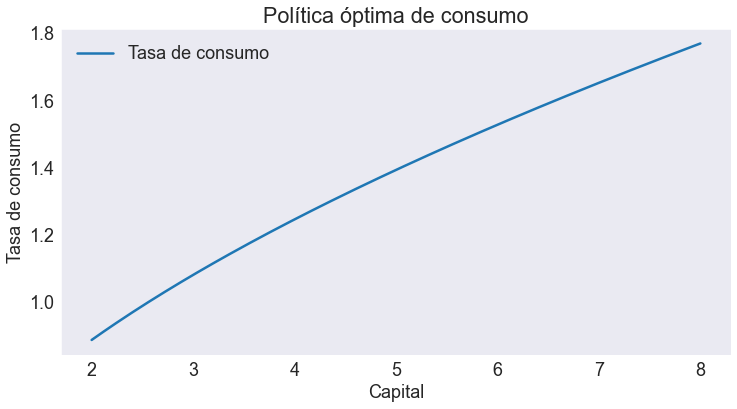

In [64]:
# Plot optimal policy
fig, ax = plt.subplots()
data2[model.controls].plot(ax=ax)
ax.set(title='Política óptima de consumo',
       ylabel=model.controls[0])
fig.savefig("SRKC-fig-consumo-capital.pdf", bbox_inches='tight')

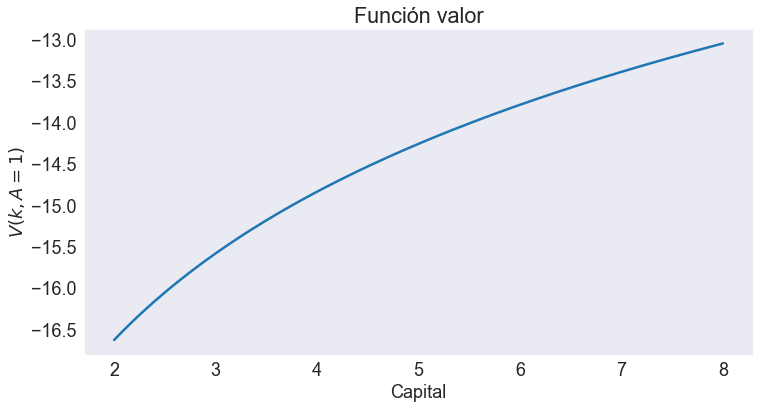

In [71]:
# Plot value function
fig, ax = plt.subplots()
data2['Value'].plot(ax=ax)
ax.set(title='Función valor',
        ylabel='$V(k, A=1)$')

fig.savefig("SRKC-fig-valor.pdf", bbox_inches='tight')

[Text(0.5, 1.0, 'Shadow Price Function'), Text(0, 0.5, 'Shadow Price')]

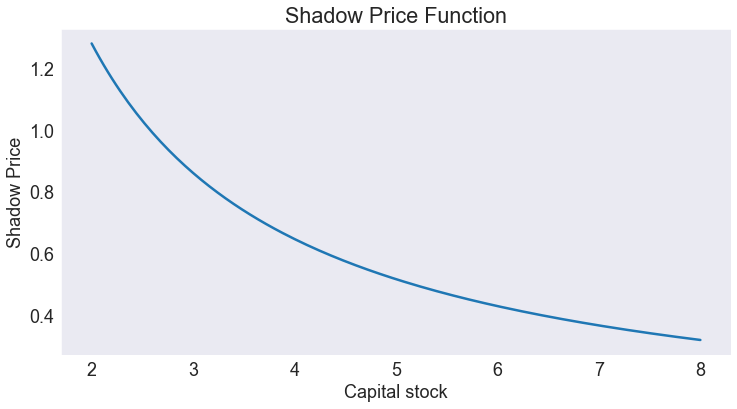

In [31]:
# Plot shadow price function
fig, ax = plt.subplots()
data2['shadow'].plot(ax=ax)
ax.set(title='Shadow Price Function',
       ylabel='Shadow Price')

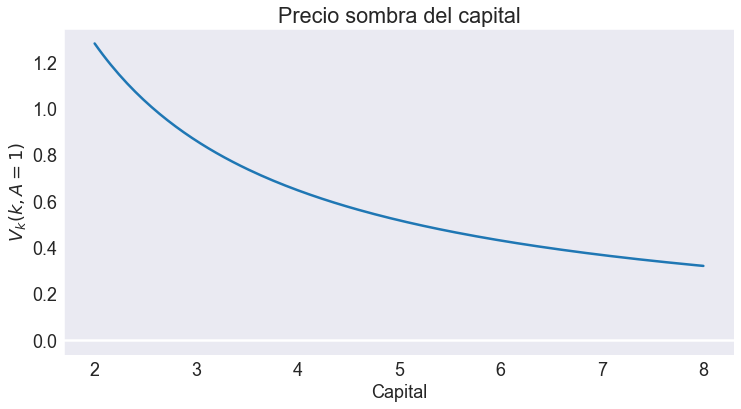

In [70]:
# Plot residual
fig, ax = plt.subplots()
ax.axhline(0, color='white')
data2['Precio sombra'].plot(ax=ax)
ax.set(title='Precio sombra del capital',
       xlabel='Capital',
       ylabel='$V_k(k, A=1)$')

fig.savefig("SRKC-fig-precio-sombra.pdf", bbox_inches='tight')

In [35]:
sinit = [3, 1]
T = 25
nrep = 2000
simulation = model.simulate(sinit, T, nrep=nrep)

Capital stock         4.252003
Productivity shock    1.000000
Consumption rate      1.279608
dtype: float64

<AxesSubplot:>

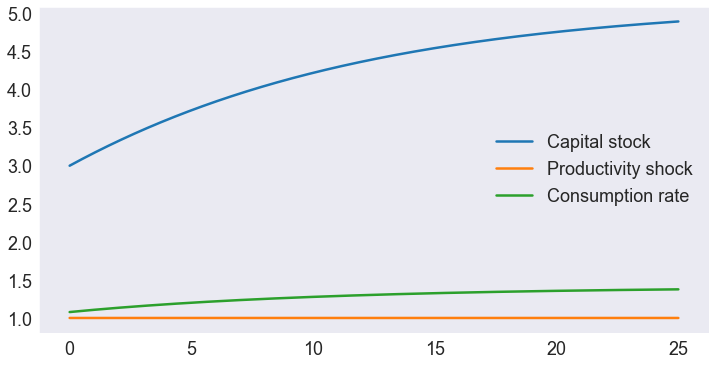

In [34]:

means = simulation.mean()


simulation.plot()


In [175]:
class ItoProcess:
    
    def __init__(self, drift, diffusion, name='y'):
        assert callable(drift), 'drift must be a function'
        assert callable(diffusion), 'diffusion must be a function'
        self.μ = drift
        self.σ = diffusion
        self.names=[name]
        #self.ds = ds

    def transform(self, f, df, d2f):
        other = ItoProcess(
            drift=lambda s: self.μ(s)*df(s) + 0.5*self.σ(s)**2 * d2f(s),
            diffusion=lambda s: self.σ(s) * df(s)
        )
        return other

    def simulate(self, s0, T, n=1000):
        tvalues = np.linspace(0, T, n+1)
        s = np.zeros(n+1, dtype=float)
        dt = tvalues[1] - tvalues[0]
        dzvalues = np.sqrt(dt) * np.random.randn(n+1)
        for t, dz in enumerate(dzvalues):
            s[t] = s0
            s0 += (self.μ(s0)*dt + self.σ(s0) * dz)
        
        return pd.DataFrame(s, index=tvalues, columns=self.names)
    

<AxesSubplot:>

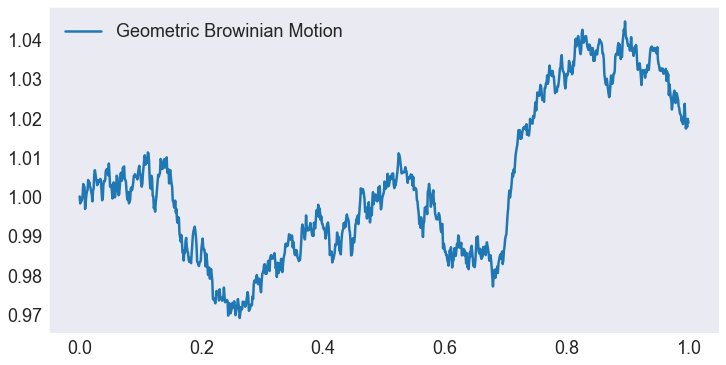

In [176]:
gbm = ItoProcess(drift=lambda s:0.1*s, diffusion=lambda s:0.05*s, name='Geometric Browinian Motion')
gbm_simul=gbm.simulate(s0=1, T=1, n=1000)
gbm_simul.plot()

<AxesSubplot:>

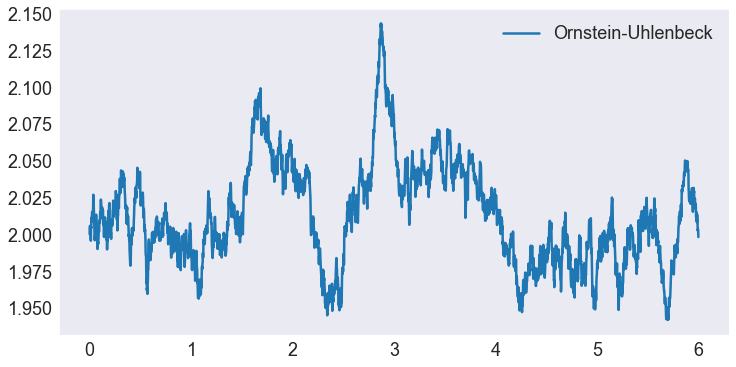

In [254]:
ou = ItoProcess(drift=lambda s: 2.5*(2-s), diffusion=lambda s:0.1, name='Ornstein-Uhlenbeck')
ou_simul=ou.simulate(s0=2, T=6, n=3000)
ou_simul.plot()

<AxesSubplot:>

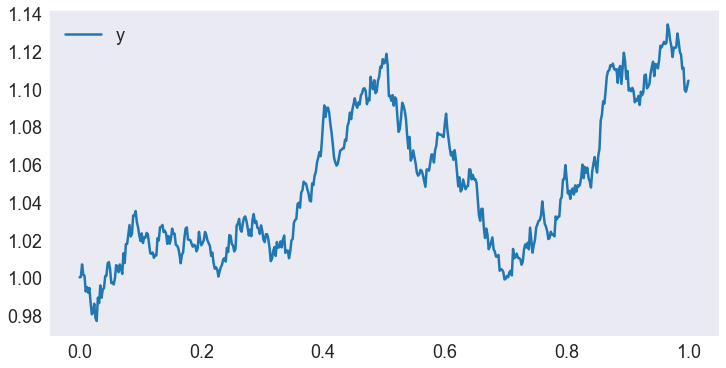

In [181]:
gbm2 = gbm.transform(lambda x: x**2, lambda x: 2*x, lambda x: 2)
gbm2_simul = gbm2.simulate(s0=1, T=1, n=500)
gbm2_simul.plot()

<AxesSubplot:>

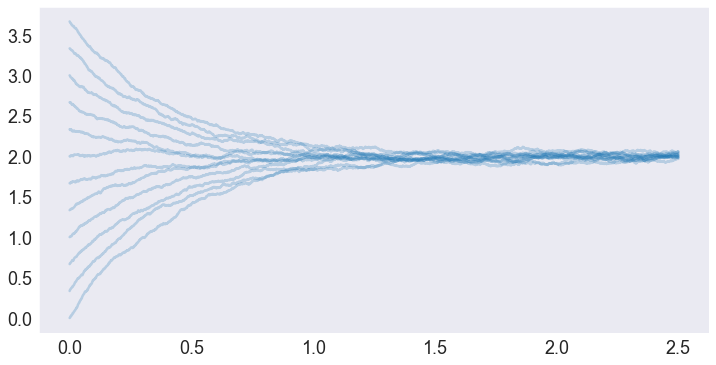

In [251]:

ou3_simul=pd.concat([ou.simulate(s0=i/3, T=2.5, n=3000) for i in range(12)], axis=1)
ou3_simul.plot(color='C0', alpha=0.25, legend=[])

In [210]:

class MultivariateItoProcess:

    def __init__(self, drift, diffusion, names='y', dz=1):
        assert callable(drift), 'drift must be a function'
        assert callable(diffusion), 'diffusion must be a function'
        self.μ = drift
        self.σ = diffusion
        self.names=names
        self.ds = len(names)
        self.dz = dz
        #self.ds = ds


    def simulate(self, s0, T=1, n=1000):
        tvalues = np.linspace(0, T, n+1)
        s = np.zeros((n+1, self.ds), dtype=float)
        dt = tvalues[1] - tvalues[0]
        dzvalues = np.sqrt(dt) * np.random.randn(n+1, self.dz)
        for t, dz in enumerate(dzvalues):
            s[t] = s0.T
            s0 += (self.μ(s0)*dt + self.σ(s0) @ dz).T

        return pd.DataFrame(s, index=tvalues, columns=self.names)

## Stochastic version of predator-prey model from demode06

<AxesSubplot:>

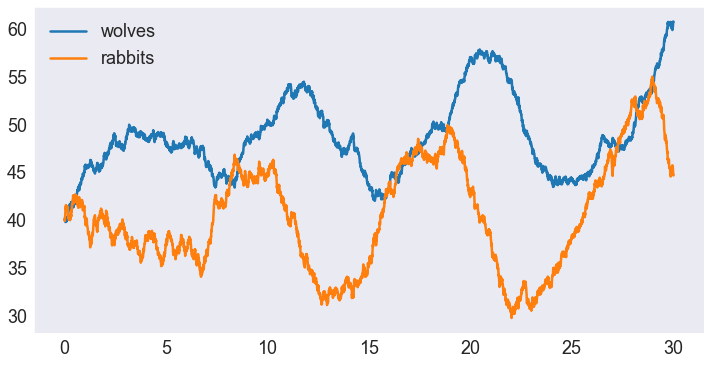

In [248]:
def drift(s):
    w, r = s # rabbits, coyotes
    wr = w*r
    return np.array([-0.4*w + 0.01*wr, 1.0*r - 0.02*wr]).T

def diffusion(s):
    return np.array([[1.4, -0.6], [-0.6, 2.25]])

proceso = MultivariateItoProcess(drift= drift, diffusion=diffusion,  names=['wolves', 'rabbits'], dz=2)
proceso.simulate(s0=np.ones((2,1))*40,T=30, n=5000).plot()

In [ ]:
# Otra version, similar a mi clase

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from compecon import BasisChebyshev

### Model parameters
𝛼 =  0.4        # capital share
𝛿 =  0.1        # capital depreciation rate
𝜃 =  2.0        # relative risk aversion
γ =  0.5        # productivity mean reversion coefficient
σ =  0.05       # productivity volatility
𝜌 =  0.05       # continuous discount rate

### Approximation structure
n = 15          # number of basis functions
kmin, kmax = 2, 8    # capital stock range
basis = BasisChebyshev(n, kmin, kmax)  # basis functions

## Solve HJB equation by collocation
#k = basis.nodes[0]
basis.y = ((𝜌*k)**(1-𝜃))/(1-𝜃)


def control(k, Vk, 𝛼,𝛿,γ,𝜃,σ):
    return Vk**(-1/𝜃)

def reward(k, c, 𝛼,𝛿,γ,𝜃,σ):
    return (1/(1-𝜃)) * c**(1-𝜃)

def drift(k, c, 𝛼,𝛿,γ,𝜃,σ):
    return k**𝛼 - c - (𝛿 - σ**2)*k

def diffusion(k, c, 𝛼,𝛿,γ,𝜃,σ):
    out = np.zeros([1,1,k.size])
    out[0, 0] = -σ*k
    return out

In [52]:
model = OCmodel(basis=basis,
                control=control, reward=reward, drift=drift, diffusion=diffusion,
                states=['Capital stock'], controls=['Consumption rate'],
                rho=𝜌, params=[𝛼,𝛿,γ,𝜃,σ])
data = model.solve()



## Simulate the model
k0 = kmin  # initial capital stock
T  = 50    # time horizon
#simulation = model.simulate([k0], T)



Solving optimal control model
iter change       time    
------------------------------
   0       9.8e+00    0.0030
   1       3.4e-01    0.0038
   2       7.4e-02    0.0039
   3       4.5e-03    0.0039
   4       1.2e-05    0.0039
   5       9.3e-11    0.0049
Elapsed Time =    0.00 Seconds


array([<AxesSubplot:xlabel='Capital stock'>, <AxesSubplot:xlabel='Capital stock'>,
       <AxesSubplot:xlabel='Capital stock'>, <AxesSubplot:xlabel='Capital stock'>], dtype=object)

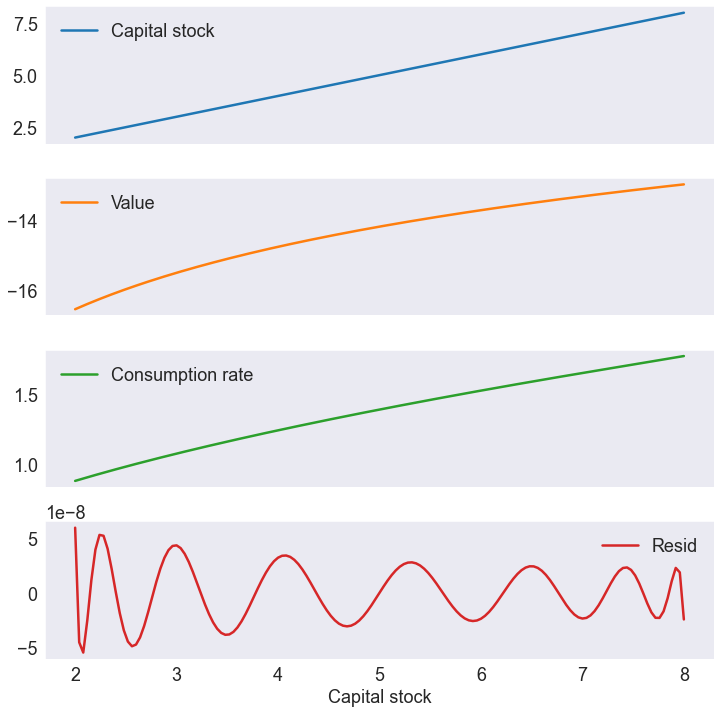

In [55]:
data.plot(subplots=True, figsize=[12,12])